# Position-Conditioned Noise Encoder based Quantum GAN

In [1]:
# !pip install jax jaxlib

In [2]:
# !pip install -U "jax[cuda13]"

In [3]:
# !pip install pennylane tensorcircuit-ng

In [4]:
# # 1. Nuclear option: remove all potential JAX conflicts
# !pip uninstall -y jax jaxlib jax-cuda12-plugin jax-cuda13-plugin jax-cuda12-pjrt jax-cuda13-pjrt

# # 2. Reinstall ONLY the one that matches your drivers (usually cuda12 is safest)
# !pip install -U "jax[cuda13]"

In [5]:
# !pip install pennylane-lightning-gpu

In [6]:
# !pip install gast

In [7]:
import os
import random

import jax
import jax.numpy as jnp

os.environ['TORCH_USE_CUDA_DSA'] = "1"
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"

# Verify with the new 2026 JAX backend check
import jax
from jax.extend import backend
try:
    print(f"Active Backend: {backend.get_backend().platform}")
    print(f"Devices: {jax.devices()}")
except Exception as e:
    print(f"Error: {e}")

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data

import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torchvision import datasets, transforms
import torchvision.transforms as transforms

from torch.utils.dlpack import from_dlpack as f2d, to_dlpack as t2d
# from jax.dlpack import from_dlpack as d2j, to_dlpack as j2d
from jax.dlpack import from_dlpack as d2j
# from jax.numpy import from_dlpack as d2j, to_dlpack as j2d
# from jax.numpy import from_dlpack as d2j

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import pennylane as qml

from tqdm import tqdm
from matplotlib import cm
from scipy.linalg import sqrtm
from sklearn.decomposition import PCA

import tensorcircuit as tc
from tensorcircuit.interfaces import torch_interface

K = tc.set_backend("jax")
print("K:", K)

import time

Active Backend: gpu
Devices: [CudaDevice(id=0)]
K: jax_backend


In [8]:
def j2d(x, stream=None):
    return x.__dlpack__(stream=stream)

In [9]:
cudnn.benchmark = True

if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator()
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [10]:
def get_train_data(dataset='MNIST', ds_class=5):
    if dataset == 'MNIST':
        train_loader = torch.utils.data.DataLoader(datasets.MNIST('../mnist', 
                                                                download=True, 
                                                                train=True,
                                                                
                                                                transform=transforms.Compose([
                                                                    torchvision.transforms.ToTensor(),
                                                                    transforms.Lambda(torch.flatten),
                                                                ])), 
                                                batch_size=10000, 
                                                shuffle=True)
    elif dataset == 'Fashion':
        train_loader = torch.utils.data.DataLoader(datasets.FashionMNIST('../fashion', 
                                                                download=True, 
                                                                train=True,
                                                                
                                                                transform=transforms.Compose([
                                                                    torchvision.transforms.ToTensor(),
                                                                    transforms.Lambda(torch.flatten),
                                                                ])), 
                                                batch_size=10000, 
                                                shuffle=True)
    elif dataset == 'KMNIST':
        train_loader = torch.utils.data.DataLoader(datasets.FashionMNIST('../kmnist', 
                                                                download=True, 
                                                                train=True,
                                                                
                                                                transform=transforms.Compose([
                                                                    torchvision.transforms.ToTensor(),
                                                                    transforms.Lambda(torch.flatten),
                                                                ])), 
                                                batch_size=10000, 
                                                shuffle=True)
    elif dataset == 'QMNIST':
        train_loader = torch.utils.data.DataLoader(datasets.FashionMNIST('../qmnist', 
                                                                download=True, 
                                                                train=True,
                                                                
                                                                transform=transforms.Compose([
                                                                    torchvision.transforms.ToTensor(),
                                                                    transforms.Lambda(torch.flatten),
                                                                ])), 
                                                batch_size=10000, 
                                                shuffle=True)
    elif dataset == 'EMNIST':
        train_loader = torch.utils.data.DataLoader(datasets.FashionMNIST('../emnist', 
                                                                download=True, 
                                                                train=True,
                                                                
                                                                transform=transforms.Compose([
                                                                    torchvision.transforms.ToTensor(),
                                                                    transforms.Lambda(torch.flatten),
                                                                ])), 
                                                batch_size=10000, 
                                                shuffle=True)
    train_data = []
    label_to_keep = ds_class
    label_to_keep_name = str(label_to_keep)
    for (data, labels) in train_loader:
        for x, y in zip(data, labels):
            # print(y)
            if y == label_to_keep:
                train_data.append(x.numpy())

    return label_to_keep_name, train_data

In [11]:
def scale_data(data, scale=None, dtype=np.float32):
    if scale is None:
        scale = [-1, 1]
    min_data, max_data = [float(np.min(data)), float(np.max(data))]
    min_scale, max_scale = [float(scale[0]), float(scale[1])]
    data = ((max_scale - min_scale) * (data - min_data) / (max_data - min_data)) + min_scale
    return data.astype(dtype)

In [12]:
# Function from https://machinelearningmastery.com/how-to-implement-the-frechet-inception-distance-fid-from-scratch/
def calculate_fid(act1, act2):
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def calculate_fid(act1, act2, eps=1e-6):
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    offset = np.eye(sigma1.shape[0]) * eps
    sigma1_stable = sigma1 + offset
    sigma2_stable = sigma2 + offset

    sigma1, sigma2 = sigma1_stable, sigma2_stable
    
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

In [13]:
label_to_keep_name, train_data = get_train_data(dataset='Fashion', ds_class=6)

In [14]:
train_data = scale_data(np.array(train_data), [0,1])

In [15]:
pca_dims=64

In [16]:
pca = PCA(n_components=pca_dims)
pca_data_full = pca.fit_transform(train_data)

In [17]:
label_to_keep_name

'6'

In [18]:
pca_data_full.shape, train_data.shape

((6000, 64), (6000, 784))

In [19]:
image_size = 8
position_encoding = 0
batch_size = 8
n_qubits = image_size + (position_encoding)
q_depth = 6 
n_generators = 8
MOSAIQ_ordering = False

In [20]:
ordering = []

In [21]:
if MOSAIQ_ordering is True:
    # for i in range(8):
    for i in range(n_generators):
        k = (image_size-1)*i
        l = [n_generators*image_size - i - k for i in range(1, image_size)]
        ordering.append([i] + (l[::-1] if i%2==1 else l))
else:
    ordering = [list(range(i*image_size, (i+1)*image_size)) for i in range(n_generators)]

pca_min, pca_max = np.min(pca_data_full), np.max(pca_data_full)

In [22]:
full_train_data = [(i,j) for i,j in zip(scale_data(pca_data_full), train_data)]

transform = transforms.Compose([transforms.ToTensor()])
dataloader = torch.utils.data.DataLoader(
    scale_data(pca_data_full), batch_size=batch_size, shuffle=True, drop_last=True
)

In [23]:
class D_PCNE_QGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(pca_dims, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

class D_PCNE_QGAN_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Layer 1: Wider start to capture PCA correlations
            nn.Linear(pca_dims, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3), # Essential: Prevents D from becoming too perfect
            
            # Layer 2: Intermediate processing
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            
            # Layer 3: Final decision
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

In [24]:
# dev = qml.device("lightning.qubit", wires=n_qubits)
# dev = qml.device("lightning.gpu", wires=n_qubits)
dev = qml.device("default.qubit", wires=n_qubits)

# @qml.qnode(dev, interface="torch", diff_method="parameter-shift")
# @qml.qnode(dev, interface="jax", diff_method="parameter-shift")

# @qml.qnode(dev, interface="jax", diff_method="parameter-shift")
# @qml.qnode(dev, interface="torch", diff_method="parameter-shift")
# @jax.jit
# @qml.qnode(dev, interface="jax")
# def quantum_circuit_PCNE_QGAN(inputs, weights, weights_ne):  # input: (32, 8, 5) -> (32, 8, 5+1)
#     # # weights = weights.reshape(q_depth, n_qubits)
#     # for i in range(n_qubits):
#     #     qml.RY(inputs[i], wires=i)
#     #     qml.RX(inputs[i], wires=i)
#     qml.AngleEmbedding(features=inputs, wires=range(n_qubits), rotation='Y')
#     qml.AngleEmbedding(features=inputs, wires=range(n_qubits), rotation='X')

#     q_depth_ne, n_qubits_full = weights_ne.shape
#     q_depth_vqc, n_qubits_vqc = weights.shape

#     assert n_qubits_full == n_qubits_vqc + position_encoding
#     assert n_qubits_full == n_qubits
    
    # for i in range(q_depth_ne):
    #     for y in range(n_qubits):
    #         qml.RY(weights_ne[i][y], wires=y)
    #     for y in range(n_qubits):
    #         qml.CZ(wires=[y, (y + 1)%n_qubits])

#     for i in range(q_depth_vqc):
#         for y in range(n_qubits_vqc):
#             qml.RY(weights[i][y], wires=y)
#         for y in range(n_qubits_vqc):
#             qml.CZ(wires=[y, (y + 1)%n_qubits_vqc])
    
#     return [qml.expval(qml.PauliX(i)) for i in range(n_qubits_vqc)]

@jax.jit
@qml.qnode(dev, interface="jax")
def quantum_circuit_PCNE_QGAN(inputs, weights):  # input: (32, 8, 5) -> (32, 8, 5+1)
    # # weights = weights.reshape(q_depth, n_qubits)
    # for i in range(n_qubits):
    #     qml.RY(inputs[i], wires=i)
    #     qml.RX(inputs[i], wires=i)
    qml.AngleEmbedding(features=inputs, wires=range(n_qubits), rotation='Y')
    qml.AngleEmbedding(features=inputs, wires=range(n_qubits), rotation='X')
    
    q_depth_vqc, n_qubits_vqc = weights.shape
    
    assert n_qubits_full == n_qubits

    for i in range(q_depth_vqc):
        for y in range(n_qubits_vqc):
            qml.RY(weights[i][y], wires=y)
        for y in range(n_qubits_vqc):
            qml.CZ(wires=[y, (y + 1)%n_qubits_vqc])
    
    return [qml.expval(qml.PauliX(i)) for i in range(n_qubits_vqc)]

# @jax.jit
@qml.qnode(dev, interface="torch")
def quantum_circuit_MOSAIQ(inputs, weights):  # input: (32, 8, 5) -> (32, 8, 5+1)
    # # weights = weights.reshape(q_depth, n_qubits)
    # for i in range(n_qubits):
    #     qml.RY(inputs[i], wires=i)
    #     qml.RX(inputs[i], wires=i)
    qml.AngleEmbedding(features=inputs, wires=range(n_qubits), rotation='Y')
    qml.AngleEmbedding(features=inputs, wires=range(n_qubits), rotation='X')
    
    q_depth_vqc, n_qubits_vqc = weights.shape
    
    # assert n_qubits_full == n_qubits

    for i in range(q_depth_vqc):
        for y in range(n_qubits_vqc):
            qml.RY(weights[i][y], wires=y)
        for y in range(n_qubits_vqc):
            qml.CZ(wires=[y, (y + 1)%n_qubits_vqc])
    
    return [qml.expval(qml.PauliX(i)) for i in range(n_qubits_vqc)]

In [25]:
def tc_MOSAIQ(inputs, weights):
    c = tc.Circuit(n_qubits)

    # print("shapes:", inputs.shape, weights.shape)
    
    for i in range(n_qubits):
        c.ry(i, theta=inputs[i])
        c.rx(i, theta=inputs[i])

    q_depth_vqc, n_qubits_vqc = weights.shape

    for i in range(q_depth_vqc):
        for y in range(n_qubits_vqc):
            c.ry(y, theta=weights[i][y])
        for y in range(n_qubits_vqc):
            c.cz(y, (y + 1)%n_qubits_vqc)

    return jnp.array([K.real(c.expectation_ps(x=[i])) for i in range(n_qubits)])
    
    # results = []
    # for i in range(switch):
    #     # expectation_ps uses dictionaries for Pauli operators
    #     # switch=8, ancilla=9. Remaining data wires are 0-7.
        
    #     res = c.expectation_ps(x=[switch], z=[j for j in range(switch) if j != i])
    #     results.append(K.real(res))
    
    # # res = c.expectation_ps(x=[switch], z=[ancilla])
    # # results.append(K.real(res))
        
    # return jnp.array(results)

# JIT for speed
tc_MOSAIQ = jax.jit(tc_MOSAIQ)

In [26]:
def tc_MOSAIQ_noise(inputs, weights, weights_ne):
    c = tc.Circuit(n_qubits)

    print("shapes:", inputs.shape, weights.shape, weights_ne.shape)
    
    for i in range(n_qubits):
        c.ry(i, theta=inputs[i])
        c.rx(i, theta=inputs[i])

    print("shapes:", inputs.shape, weights.shape, weights_ne.shape)

    q_depth_vqc, n_qubits_vqc = weights.shape
    q_depth_ne, n_qubits_full = weights_ne.shape

    # with condition reupload
    for i in range(q_depth_ne):
        for y in range(n_qubits_full):
            c.ry(y, theta=weights_ne[i][y])
        for y in range(n_qubits):
            c.cz(y, (y + 1)%n_qubits_vqc)
        if i != (q_depth_ne - 1):
            for i in range(n_qubits):
                c.ry(i, theta=inputs[i])
                c.rx(i, theta=inputs[i])

    for i in range(q_depth_vqc):
        for y in range(n_qubits_vqc):
            c.ry(y, theta=weights[i][y])
        for y in range(n_qubits_vqc):
            c.cz(y, (y + 1)%n_qubits_vqc)

    return jnp.array([K.real(c.expectation_ps(x=[i])) for i in range(n_qubits_vqc)])
    
    # results = []
    # for i in range(switch):
    #     # expectation_ps uses dictionaries for Pauli operators
    #     # switch=8, ancilla=9. Remaining data wires are 0-7.
        
    #     res = c.expectation_ps(x=[switch], z=[j for j in range(switch) if j != i])
    #     results.append(K.real(res))
    
    # # res = c.expectation_ps(x=[switch], z=[ancilla])
    # # results.append(K.real(res))
        
    # return jnp.array(results)

# JIT for speed
tc_MOSAIQ_noise = jax.jit(tc_MOSAIQ_noise)

In [183]:
class tc_MOSAIQ_MLP(nn.Module):
    def __init__(self, weights_shape, name='QuantumMLP', q_param=None, q_delta=1):
        super().__init__()
        self.name = name
        # # Define weights as PyTorch parameters so Adam can optimize them
        # self.vqc_weights = nn.Parameter(torch.randn(weights_shape).to(torch.device('cuda')))
        # # self.vqc_weights = nn.Parameter(torch.zeros(weights_shape).to(torch.device('cuda')))
        
        # self.mixing_weights = nn.Parameter(torch.randn(mixing_weights).to(torch.device('cuda')))

        self.qlayer = tc.TorchLayer(
            tc_MOSAIQ, 
            weights_shape=weights_shape,
            use_vmap=True,
            vectorized_argnums=[0],
            initializer=[
                lambda shape: q_param if q_param is not None else q_delta * torch.randn(shape) # For vqc_weights
            ]
        ).to(torch.device('cuda'))

    def forward(self, x):
        return self.qlayer(x)

In [184]:
class tc_MOSAIQ_MLP_noise(nn.Module):
    def __init__(self, weights_shape, weights_ne_shape, name='QuantumMLPNoise'):
        super().__init__()
        self.name = name
        # # Define weights as PyTorch parameters so Adam can optimize them
        # self.vqc_weights = nn.Parameter(torch.randn(weights_shape).to(torch.device('cuda')))
        # # self.vqc_weights = nn.Parameter(torch.zeros(weights_shape).to(torch.device('cuda')))
        
        # self.mixing_weights = nn.Parameter(torch.randn(mixing_weights).to(torch.device('cuda')))
        # print("weights_shape:", weights_shape, weights_ne_shape)

        self.qlayer = tc.TorchLayer(
            tc_MOSAIQ_noise, 
            weights_shape=[weights_shape, weights_ne_shape],
            use_vmap=True,
            vectorized_argnums=[0, None, None],
            initializer=[
                lambda shape: torch.randn(shape), # For vqc_weights
                lambda shape: torch.randn(shape)  # For mixing_weights
            ]
        ).to(torch.device('cuda'))

        # self.qlayer = tc.TorchLayer(
        #     tc_MOSAIQ_noise, 
        #     weights_shape={0: weights_shape, 1: weights_ne_shape},
        #     use_vmap=True,
        #     vectorized_argnums=[0]
        # ).to(torch.device('cuda'))

        # vmapped_f = tc.backend.vmap(tc_MOSAIQ_noise, vectorized_argnums=[0])
        # self.f = torch_interface(vmapped_f, jit=True)

        # self.vqc_weights = nn.Parameter(torch.randn(weights_shape))
        # self.ne_weights = nn.Parameter(torch.randn(weights_ne_shape))

    def forward(self, x):
        # return self.f(x, self.vqc_weights, self.ne_weights)
        return self.qlayer(x)

In [185]:
ordering

[[0, 1, 2, 3, 4, 5, 6, 7],
 [8, 9, 10, 11, 12, 13, 14, 15],
 [16, 17, 18, 19, 20, 21, 22, 23],
 [24, 25, 26, 27, 28, 29, 30, 31],
 [32, 33, 34, 35, 36, 37, 38, 39],
 [40, 41, 42, 43, 44, 45, 46, 47],
 [48, 49, 50, 51, 52, 53, 54, 55],
 [56, 57, 58, 59, 60, 61, 62, 63]]

In [186]:
jax_circuit__1 = jax.jit(quantum_circuit_PCNE_QGAN)
vmap_circuit = jax.vmap(jax_circuit__1, in_axes=(0, None, None))

jax_circuit__2 = jax.jit(quantum_circuit_MOSAIQ)
vmap_circuit = jax.vmap(jax_circuit__2, in_axes=(0, None))

In [187]:
class JAXQuantumFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, inputs, weights, weights_ne):
        jax_gpu = jax.devices("gpu")[0]
        # jax_in = jax.device_put(d2j(t2d(inputs.detach())), jax_gpu)
        # jax_w = jax.device_put(d2j(t2d(weights.detach())), jax_gpu)
        # jax_w_ne = jax.device_put(d2j(t2d(weights_ne.detach())), jax_gpu)

        jax_in = jax.device_put(d2j(inputs.detach()).reshape(-1, n_qubits), jax_gpu)
        jax_w = jax.device_put(d2j(weights.detach()), jax_gpu)
        jax_w_ne = jax.device_put(d2j(weights_ne.detach()), jax_gpu)
        
        # jax_mixing_weights = jax.device_put(d2j(t2d(mixing_weights.detach())), jax_gpu)
        
        # 1. Define a wrapper that ensures the output is ALWAYS a JAX array
        # This allows JAX to 'trace' the stacking logic
        def consolidated_model(i, w, w_ne):
            # print("shape of i, w, w_ne in JAXQuantumFunction:", i.shape, w.shape, w_ne.shape)
            out = vmap_circuit(i, w, w_ne)
            # print("shape of out in JAXQuantumFunction:", out.shape)
            if isinstance(out, (list, tuple)):
                return jnp.stack(out, axis=-1)
            return out

        # 2. Compute VJP on the consolidated model
        val, jax_vjp_fn = jax.vjp(consolidated_model, jax_in, jax_w, jax_w_ne)
        
        ctx.jax_vjp_fn = jax_vjp_fn
        # Return to Torch
        return f2d(j2d(val))

    @staticmethod
    def backward(ctx, grad_output):
        # 1. Detect device from the incoming gradient
        current_device = grad_output.device
        jax_gpu = jax.devices("gpu")[0]
        
        # 2. Convert to JAX for calculation
        # jax_grad_out = jax.device_put(d2j(t2d(grad_output.detach())), jax_gpu)
        jax_grad_out = jax.device_put(d2j(grad_output.detach().contiguous()), jax_gpu)
        
        # 3. JAX backward pass
        # grad_inputs, grad_weights, grad_mixing = ctx.jax_vjp_fn(jax_grad_out)
        grad_inputs, grad_weights, grad_weights_ne = ctx.jax_vjp_fn(jax_grad_out)
        
        # 4. Convert back to Torch and FORCE the device metadata
        # We use .to(current_device) to ensure it matches exactly
        # return (
        #     f2d(j2d(grad_inputs)).to(current_device), 
        #     f2d(j2d(grad_weights)).to(current_device),
        #     f2d(j2d(grad_weights_ne)).to(current_device)
        #     # f2d(j2d(grad_mixing)).to(current_device)
        # )

        return (
            f2d(grad_inputs).to(current_device), 
            f2d(grad_weights).to(current_device),
            f2d(grad_weights_ne).to(current_device)
            # f2d(j2d(grad_mixing)).to(current_device)
        )

In [188]:
class JAXQuantumFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, inputs, weights):
        jax_gpu = jax.devices("gpu")[0]
        # jax_in = jax.device_put(d2j(t2d(inputs.detach())), jax_gpu)
        # jax_w = jax.device_put(d2j(t2d(weights.detach())), jax_gpu)
        # jax_w_ne = jax.device_put(d2j(t2d(weights_ne.detach())), jax_gpu)

        jax_in = jax.device_put(d2j(inputs.detach()).reshape(-1, n_qubits), jax_gpu)
        jax_w = jax.device_put(d2j(weights.detach()), jax_gpu)
        
        # jax_mixing_weights = jax.device_put(d2j(t2d(mixing_weights.detach())), jax_gpu)
        
        # 1. Define a wrapper that ensures the output is ALWAYS a JAX array
        # This allows JAX to 'trace' the stacking logic
        def consolidated_model(i, w):
            # print("shape of i, w, w_ne in JAXQuantumFunction:", i.shape, w.shape, w_ne.shape)
            out = vmap_circuit(i, w)
            # print("shape of out in JAXQuantumFunction:", out.shape)
            if isinstance(out, (list, tuple)):
                return jnp.stack(out, axis=-1)
            return out

        # 2. Compute VJP on the consolidated model
        val, jax_vjp_fn = jax.vjp(consolidated_model, jax_in, jax_w)
        
        ctx.jax_vjp_fn = jax_vjp_fn
        # Return to Torch
        return f2d(j2d(val))

    @staticmethod
    def backward(ctx, grad_output):
        # 1. Detect device from the incoming gradient
        current_device = grad_output.device
        jax_gpu = jax.devices("gpu")[0]
        
        # 2. Convert to JAX for calculation
        # jax_grad_out = jax.device_put(d2j(t2d(grad_output.detach())), jax_gpu)
        jax_grad_out = jax.device_put(d2j(grad_output.detach().contiguous()), jax_gpu)
        
        # 3. JAX backward pass
        # grad_inputs, grad_weights, grad_mixing = ctx.jax_vjp_fn(jax_grad_out)
        grad_inputs, grad_weights = ctx.jax_vjp_fn(jax_grad_out)

        return (
            f2d(grad_inputs).to(current_device), 
            f2d(grad_weights).to(current_device)
        )

In [189]:
n_generators

8

In [190]:
class QuantumMLP(nn.Module):
    def __init__(self, q_delta, q_depth, q_depth_ne, n_qubits, position_encoding, name='QuantumMLP'):
        super().__init__()
        self.name = name
        # Define weights as PyTorch parameters so Adam can optimize them
        # self.vqc_weights = nn.Parameter(torch.randn(weights_shape).to(torch.device('cuda')))
        # self.vqc_weights = nn.Parameter(torch.zeros(weights_shape).to(torch.device('cuda')))
        
        # self.q_params = nn.ParameterList(
        #     [nn.Parameter(q_delta * torch.rand(q_depth, n_qubits-position_encoding), requires_grad=True),
        #      nn.Parameter(q_delta * torch.rand(q_depth_ne, n_qubits), requires_grad=True)]
        # )

        self.q_params = nn.ParameterList(
            [nn.Parameter(q_delta * torch.rand(q_depth, n_qubits-position_encoding), requires_grad=True)]
        )
        
        # self.mixing_weights = nn.Parameter(torch.randn(mixing_weights).to(torch.device('cuda')))

    def forward(self, x):
        # out = JAXQuantumFunction.apply(x, self.q_params[0], self.q_params[1])
        print("shape of x:", x.shape)
        out = JAXQuantumFunction.apply(x, self.q_params[0])
        
        return out

In [191]:
class QuantumMLP_MOSAIQ(nn.Module):
    def __init__(self, name='QuantumMLP_MOSAIQ'):
        super().__init__()
        self.name = name

    def forward(self, x, weight):
        # out = JAXQuantumFunction.apply(x, self.q_params[0], self.q_params[1])
        # print("shape of x:", x.shape)
        out = JAXQuantumFunction.apply(x, weight)
        
        return out

In [192]:
class QuantumGenerator_PCNE_QGAN(nn.Module):
    def __init__(self, n_generators, position_encoding, q_depth_ne, q_depth, q_delta=1, env='simulation'):
        super().__init__()

        # self.q_params = nn.ParameterList(
        #     [
        #         nn.Parameter(q_delta * torch.rand(q_depth, n_qubits), requires_grad=True)
        #         for _ in range(n_generators)
        #     ]
        # )
        # self.q_params = [nn.Parameter(q_delta * torch.rand(q_depth, n_qubits-position_encoding), requires_grad=True),
        #                  nn.Parameter(q_delta * torch.rand(q_depth_ne, n_qubits), requires_grad=True)]

        self.n_generators = n_generators
        self.env = env

        # weight_shapes = {"weights": (q_depth, n_qubits)}
        # if env == "real":
        #     self.qcircuit = qml.qnn.TorchLayer(quantum_cirtui_real_machine, weight_shapes).to(device)
        # else:
        #     self.qcircuit = qml.qnn.TorchLayer(quantum_circuit_MosaiQ, weight_shapes).to(device)

        # weight_shapes = {
        #     "weights": (q_depth, n_qubits-position_encoding),
        #     "weights_ne": (q_depth_ne, n_qubits),
        # }
        
        # init_method = {
        #     "weights": nn.Parameter(q_delta * torch.rand(q_depth, n_qubits-position_encoding), requires_grad=True),
        #     "weights_ne":  nn.Parameter(q_delta * torch.rand(q_depth_ne, n_qubits), requires_grad=True),
        # }
        # self.generator_torch_layer = qml.qnn.TorchLayer(quantum_circuit_PCNE_QGAN, weight_shapes=weight_shapes, init_method=init_method).to(device)
        
        # self.generator_torch_layer = QuantumMLP(q_delta, q_depth, q_depth_ne, n_qubits, position_encoding).to(device)
        # self.generator_torch_layer = QuantumMLP_MOSAIQ().to(device)
        # self.generator_torch_layer = tc_MOSAIQ_MLP_noise((q_depth, n_qubits-position_encoding), (q_depth_ne, n_qubits)).to(device)

        self.generator_torch_layer = tc.TorchLayer(
            tc_MOSAIQ_noise, 
            weights_shape=[(q_depth, n_qubits-position_encoding), (q_depth_ne, n_qubits-position_encoding)],
            use_vmap=True,
            vectorized_argnums=[0],
            initializer=[
                lambda shape: torch.randn(shape), # For vqc_weights
                lambda shape: torch.randn(shape)  # For mixing_weights
            ]
        ).to(torch.device('cuda'))

    def forward(self, x):
        # print("x shape:", x.shape)  # (batch_size, length of noise)
        images = []
        patch_size = image_size
        images = torch.Tensor(x.size(0), 0).to(device)
        batch_size, len_data = x.shape

        x = x.unsqueeze(1)  # (32, 1, 5)
        x = x.expand(-1, n_generators, -1)  # (32, 8, 5)
        # print("x:", x)
        pos_values = torch.linspace(np.pi/4, 2*np.pi, steps=n_generators).to(device)
        pos_values = pos_values.view(1, n_generators, 1)
        pos_values = pos_values.expand(batch_size, -1, -1)  # (32, 8, 5)
        pos_values = pos_values.view(batch_size, n_generators, 1)
        x = torch.cat((x, pos_values), dim=2)
        # print("x:", x)
        # print("x shape:", x.shape, type(x))

        x_flat = x.view(-1, x.shape[-1]) 
        # output_flat = self.generator_torch_layer(x_flat)
        # output = output_flat.view(batch_size, n_generators, -1)

        output = self.generator_torch_layer(x_flat)
        # output = JAXQuantumFunction.apply(x, self.q_params[0], self.q_params[1])
        # print("output shape:", output.shape)

        output = output.view(batch_size, n_generators, -1)
        output = output.view(batch_size, -1)
        flattened_order = [j for sub in ordering for j in sub]
        # print("output shape:", output.shape)
        output = output[:, flattened_order]
        # print("output shape:", output.shape)
        # output = output.reshape(batch_size, patch_size)
        # print("patches shape:", output.shape)
        
        return output

In [193]:
class QuantumGenerator_MOSAIQ(nn.Module):
    def __init__(self, n_generators, position_encoding, q_depth_ne, q_depth, q_delta=1, env='simulation'):
        super().__init__()

        self.q_params = nn.ParameterList(
            [
                nn.Parameter(q_delta * torch.rand(q_depth, n_qubits), requires_grad=True)
                for _ in range(n_generators)
            ]
        ).to(device)
        # # self.q_params = [nn.Parameter(q_delta * torch.rand(q_depth, n_qubits-position_encoding), requires_grad=True),
        # #                  nn.Parameter(q_delta * torch.rand(q_depth_ne, n_qubits), requires_grad=True)]

        self.n_generators = n_generators
        self.env = env

        # weight_shapes = {"weights": (q_depth, n_qubits)}
        # if env == "real":
        #     self.qcircuit = qml.qnn.TorchLayer(quantum_cirtui_real_machine, weight_shapes).to(device)
        # else:
        #     self.qcircuit = qml.qnn.TorchLayer(quantum_circuit_MosaiQ, weight_shapes).to(device)

        self.generator_torch_layers = []
        # for _ in range(n_generators):
        #     weight_shapes = {
        #         "weights": (q_depth, n_qubits-position_encoding),
        #         # "weights_ne": (q_depth_ne, n_qubits),
        #     }
            
        #     # init_method = {
        #     #     "weights": nn.Parameter(q_delta * torch.rand(q_depth, n_qubits-position_encoding), requires_grad=True),
        #     #     # "weights_ne":  nn.Parameter(q_delta * torch.rand(q_depth_ne, n_qubits), requires_grad=True),
        #     # }
        #     init_method = {
        #         "weights": self.q_params[_],
        #         # "weights_ne":  nn.Parameter(q_delta * torch.rand(q_depth_ne, n_qubits), requires_grad=True),
        #     }
        #     self.generator_torch_layers.append(qml.qnn.TorchLayer(quantum_circuit_MOSAIQ, weight_shapes=weight_shapes, init_method=init_method).to(device))        

        for _ in range(n_generators):
            self.generator_torch_layers.append(tc_MOSAIQ_MLP((q_depth, n_qubits-position_encoding), q_param=self.q_params[_], q_delta=q_delta).to(device))
            
            # temp_tc = tc.TorchLayer(
            #     tc_MOSAIQ, 
            #     weights_shape=(q_depth, n_qubits-position_encoding),
            #     use_vmap=True,
            #     vectorized_argnums=[0],
            #     initializer=[
            #         lambda shape: q_delta * torch.randn(shape) # For vqc_weights
            #     ]
            # ).to(torch.device('cuda'))
            # print(temp_tc)
            # self.generator_torch_layers.append(temp_tc)
        
        # self.generator_torch_layer = QuantumMLP(q_delta, q_depth, q_depth_ne, n_qubits, position_encoding).to(device)
        # self.generator_torch_layer = QuantumMLP_MOSAIQ().to(device)
        # self.generator_torch_layer = qml.qnn.TorchLayer(quantum_circuit_MOSAIQ).to(device)

    def forward(self, x):
        # print("x shape:", x.shape)  # (batch_size, length of noise)
        images = []
        patch_size = image_size
        images = torch.Tensor(x.size(0), 0).to(device)
        batch_size, len_data = x.shape

        # x = x.unsqueeze(1)  # (32, 1, 5)
        # x = x.expand(-1, n_generators, -1)  # (32, 8, 5)
        # # print("x:", x)
        # pos_values = torch.linspace(np.pi/4, 2*np.pi, steps=n_generators).to(device)
        # pos_values = pos_values.view(1, n_generators, 1)
        # pos_values = pos_values.expand(batch_size, -1, -1)  # (32, 8, 5)
        # pos_values = pos_values.view(batch_size, n_generators, 1)
        # x = torch.cat((x, pos_values), dim=2)
        # print("x:", x)
        # print("x shape:", x.shape)

        
        # output = self.generator_torch_layer(x)
        # output = torch.stack([self.generator_torch_layer(x, self.q_params[_]) for _ in range(self.n_generators)])
        output = torch.stack([self.generator_torch_layers[_](x) for _ in range(self.n_generators)])
        # output = JAXQuantumFunction.apply(x, self.q_params[0], self.q_params[1])
        # print("output shape:", output.shape)

        output = output.view(batch_size, n_generators, -1)
        output = output.view(batch_size, -1)
        flattened_order = [j for sub in ordering for j in sub]
        # print("flattened_order", flattened_order)
        # print("output shape:", output.shape)
        output = output[:, flattened_order]
        # print("output shape:", output.shape)
        # output = output.reshape(batch_size, patch_size)
        # print("patches shape:", output.shape)
        
        return output

In [194]:
class ClassicalGenerator(nn.Module):
    def __init__(self, noise_shape):
        super().__init__()
        
        self.model = nn.Sequential(
            # First Layer: Upsample noise
            nn.Linear(noise_shape, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Second Layer: Create internal features
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Third Layer: Refine features
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Final Layer: Map to PCA space
            nn.Linear(64, pca_dims),
            # Use Tanh if your PCA data is normalized [-1, 1] 
            # Use Sigmoid if your PCA data is [0, 1]
            nn.Tanh() 
        )

    def forward(self, x):
        return self.model(x)

In [195]:
# flattened_order = [j for sub in ordering for j in sub]
# flattened_order

In [196]:
position_encoding, n_generators

(0, 8)

In [197]:
lrG = 0.3
lrD = 0.02

# lrG = 0.001
# lrD = 0.0005

num_iter = 500

gen_losses = []
disc_losses = []

discriminator = D_PCNE_QGAN().to(device)
# discriminator = D_PCNE_QGAN_2().to(device)

# generator = ClassicalGenerator(n_qubits-position_encoding).to(device)
# generator = QuantumGenerator_PCNE_QGAN(n_generators, position_encoding, 3, 6).to(device)
generator = QuantumGenerator_MOSAIQ(n_generators, position_encoding, 0, 6).to(device)

criterion = nn.BCELoss()

In [198]:
def relu(x):
    return x * (x > 0)
def get_noise_upper_bound(gen_loss, disc_loss, original_ratio):
    R = disc_loss.detach().cpu().numpy()/gen_loss.detach().cpu().numpy()
    return math.pi/8 + (5 *math.pi / 8) * relu(np.tanh((R - (original_ratio))))

In [199]:
original_ratio = None
upper_bounds = [math.pi/8]
results = []
generated_images = []

In [200]:
for name, param in generator.named_parameters():
    if param.requires_grad:
        print(f"Layer name: {name} | Trainable: {param.requires_grad} | Size: {param.size()}")

Layer name: q_params.0 | Trainable: True | Size: torch.Size([6, 8])
Layer name: q_params.1 | Trainable: True | Size: torch.Size([6, 8])
Layer name: q_params.2 | Trainable: True | Size: torch.Size([6, 8])
Layer name: q_params.3 | Trainable: True | Size: torch.Size([6, 8])
Layer name: q_params.4 | Trainable: True | Size: torch.Size([6, 8])
Layer name: q_params.5 | Trainable: True | Size: torch.Size([6, 8])
Layer name: q_params.6 | Trainable: True | Size: torch.Size([6, 8])
Layer name: q_params.7 | Trainable: True | Size: torch.Size([6, 8])


In [201]:
optD = optim.SGD(discriminator.parameters(), lr=lrD)
optG = optim.SGD(generator.parameters(), lr=lrG)

# optD = optim.Adam(discriminator.parameters(), lr=lrD)
# optG = optim.Adam(generator.parameters(), lr=lrG)


real_labels = torch.full((batch_size,), 1.0, dtype=torch.float, device=device)
fake_labels = torch.full((batch_size,), 0.0, dtype=torch.float, device=device)
counter = 0

noise_upper_bound = math.pi/8

In [202]:
adaptive_noise_enable = True

In [203]:
print('Training...')
for e in tqdm(range(num_iter)):
    st = time.time()
    for i, train_pair in enumerate(dataloader):
        pca_data = train_pair
        data = pca_data.reshape(batch_size, pca_dims)
        real_data = data.to(device).to(torch.float32)
        
        noise = torch.rand(batch_size, n_qubits-position_encoding, device=device) * (noise_upper_bound if adaptive_noise_enable else 1)
        # noise = torch.rand(batch_size, n_qubits, device=device)
        
        fake_data = generator(noise)
        # print("shape of fake_data:", fake_data.shape, real_data.shape)
        
        discriminator.zero_grad()
        outD_real = discriminator(real_data).view(-1)
        outD_fake = discriminator(fake_data.detach()).view(-1)
        errD_real = criterion(outD_real, real_labels)
        errD_fake = criterion(outD_fake, fake_labels)

        # print("shapes:", outD_fake.shape, fake_labels.shape)
        
        errD_real.backward()
        errD_fake.backward()
        errG = criterion(outD_fake, real_labels)
        errD = errD_real + errD_fake
        
        # gen_losses.append(errG.detach().cpu().numpy())
        # disc_losses.append(errD.detach().cpu().numpy())
        
        gen_losses.append(errG.detach().cpu().numpy())
        disc_losses.append(errD.detach().cpu().numpy())

        optD.step()

        # Train the generator
        generator.zero_grad()
        outD_fake = discriminator(fake_data).view(-1)
        errG = criterion(outD_fake, real_labels)
        errG.backward()
        optG.step()
        if original_ratio is None:
            original_ratio = errD.detach().cpu().numpy()/errG.detach().cpu().numpy()
        noise_upper_bound = get_noise_upper_bound(errG, errD, original_ratio)
        upper_bounds.append(noise_upper_bound)
        np.save(f'upper_bounds_{label_to_keep_name}', upper_bounds)
        counter += 1      
        # if counter % 20 == 0: 
        if i == 0:
            test_images = generator(noise).detach().cpu().numpy()
            test_images = pca.inverse_transform(test_images)
            fid = calculate_fid(test_images.reshape([batch_size, 784]), train_data)
            test_images = scale_data(test_images,[0,1])
            real_images = []
            np.save(f'gen_loss_{label_to_keep_name}', gen_losses)
            np.save(f'disc_loss_{label_to_keep_name}', disc_losses)
            from PIL import Image 
            im = np.reshape(test_images[0], [28, 28])
            new_im = np.zeros([28,28])
            for i in range(28):
                for j in range(28):
                    if im[i][j] > .5:
                        new_im[i][j] = 0.0
                    else:
                        new_im[i][j] = 1.0
            im = Image.fromarray(np.uint8(255-(new_im*255)))

            # if i == 0:
            if True:
                print("FID score:", fid)
                print("gen_loss, disc_loss:", np.mean(gen_losses), np.mean( disc_losses))
            
            # im = im.save(os.path.join("../QGAN/gen_images_dist",f"{label_to_keep_name}_{counter}.png"))  # original
            # im = im.save(os.path.join("../QGAN/gen_images_dist simple rot",f"{label_to_keep_name}_{counter}.png"))  # naive rotation
            # im = im.save(os.path.join("../QGAN/gen_images_dist same generator no noise encoder",f"{label_
            im = im.save(os.path.join("../QGAN/gen_images_dist same generator with conditioned noise encoder 8 gen PCA 40",f"{label_to_keep_name}_{counter}.png"))  # naive rotationto_keep_name}_{counter}.png"))  # naive rotation
            
            torch.save(generator.state_dict(), f"generator_{label_to_keep_name}")
            torch.save(discriminator.state_dict(), f"disc_{label_to_keep_name}")

    print(i, "time taken:", time.time() - st)

Training...


  0%|                                                                                     | 0/500 [00:00<?, ?it/s]

FID score: 46.57824568812417
gen_loss, disc_loss: 0.7689379 1.3836793


  0%|▏                                                                        | 1/500 [04:30<37:33:43, 270.99s/it]

749 time taken: 270.98950004577637
FID score: 46.423200104475626
gen_loss, disc_loss: 1.0057694 1.1916257


...

749 time taken: 70.15936279296875
FID score: 46.23080207876655
gen_loss, disc_loss: 12.280978 0.09824653


  4%|██▋                                                                       | 18/500 [24:03<9:23:20, 70.13s/it]

749 time taken: 70.87688779830933
FID score: 46.40406566936572
gen_loss, disc_loss: 12.531461 0.092921406


  4%|██▋                                                                      | 18/500 [24:52<11:05:53, 82.89s/it]


KeyboardInterrupt: 

In [ ]:
n_qubits
position_encoding

In [130]:
# vars = []
# for label in ["5"]:
#     var = []
#     label_to_keep_name = label
#     generator.load_state_dict(torch.load(f"generator_{label_to_keep_name}"))
#     outputs = np.zeros([25, 5, 784])
#     noise_max = np.load(f'upper_bounds_{label_to_keep_name}.npy')
#     for i in range(25):
#         noise = torch.rand(n_generators, n_qubits-position_encoding, device=device).to(device) * noise_max[i]
#         output = pca.inverse_transform(generator(noise).detach().cpu().numpy())
#         outputs[i] = output
#     outputs = outputs.reshape([125, 784])
#     mean = np.mean(outputs, axis=0)
#     for i in range(outputs.shape[0]):
#         var.append(np.sum(np.square(outputs[i] - mean)))
#     x = np.sort(var)
#     y = np.arange(200) / float(200)
#     vars.append((x,y))
# plt.plot(vars[0][0], vars[0][1], marker='o', label='No ADJ')
# plt.plot(vars[1][0], vars[1][1], marker='o', label='ADJ')
# np.save('vars', vars)
# plt.legend()
# plt.show()

In [131]:
train_pair = next(iter(dataloader))
pca_data = train_pair

In [132]:
train_pair.shape

torch.Size([8, 40])

In [133]:
data = pca_data.reshape(batch_size, pca_dims)

In [134]:
data.shape

torch.Size([8, 40])

In [135]:
real_data = data.to(device).to(torch.float32)
noise_upper_bound = 1
noise = torch.rand(batch_size, n_qubits-position_encoding, device=device) * noise_upper_bound

In [136]:
fake_data = generator(noise)

In [137]:
noise.shape

torch.Size([8, 5])

In [138]:
fake_data.shape

torch.Size([8, 40])

In [139]:
discriminator.zero_grad()

In [140]:
outD_real = discriminator(real_data).view(-1)

In [141]:
outD_fake = discriminator(fake_data.detach()).view(-1)

In [142]:
outD_real

tensor([1.0000, 1.0000, 0.9999, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       device='cuda:0', grad_fn=<ViewBackward0>)

In [143]:
outD_fake

tensor([3.7654e-08, 5.0365e-09, 1.3451e-07, 6.6053e-06, 3.8952e-01, 2.4469e-01,
        9.9999e-01, 9.9770e-01], device='cuda:0', grad_fn=<ViewBackward0>)

In [144]:
fake_data__pca_inv = pca.inverse_transform(fake_data.detach().cpu().numpy())

In [145]:
fake_data__pca_inv = fake_data__pca_inv.reshape(batch_size, 28, 28)

In [146]:
fake_data__pca_inv.shape

(8, 28, 28)

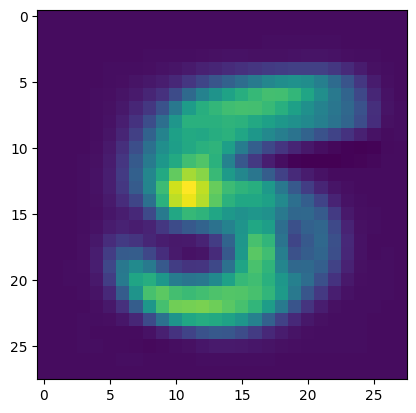

In [147]:
plt.imshow(fake_data__pca_inv[0])

In [ ]:
real_data.shape

In [ ]:
plt.imshow(pca.inverse_transform(real_data.detach().cpu().numpy()).reshape(64, 28, 28)[0])